In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("All imports successful!")

Matplotlib is building the font cache; this may take a moment.


All imports successful!


In [3]:
# Load the main historical results dataset
results = pd.read_csv('data/raw/results.csv')

print("Shape:", results.shape)
print("\nColumns:", results.columns.tolist())
print("\nFirst 5 rows:")
results.head()

Shape: (49477, 9)

Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

First 5 rows:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
# Basic info and missing values
print("Data types:")
print(results.dtypes)
print("\nMissing values:")
print(results.isnull().sum())
print("\nDate range:")
print(f"Earliest: {results['date'].min()}")
print(f"Latest: {results['date'].max()}")
print("\nUnique teams:", results['home_team'].nunique())
print("Unique tournaments:", results['tournament'].nunique())

Data types:
date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object

Missing values:
date           0
home_team      0
away_team      0
home_score    68
away_score    68
tournament     0
city           0
country        0
neutral        0
dtype: int64

Date range:
Earliest: 1872-11-30
Latest: 2026-06-27

Unique teams: 327
Unique tournaments: 200


Total World Cup matches: 1036
First WC match: 1930-07-13 00:00:00
Last WC match: 2026-06-27 00:00:00


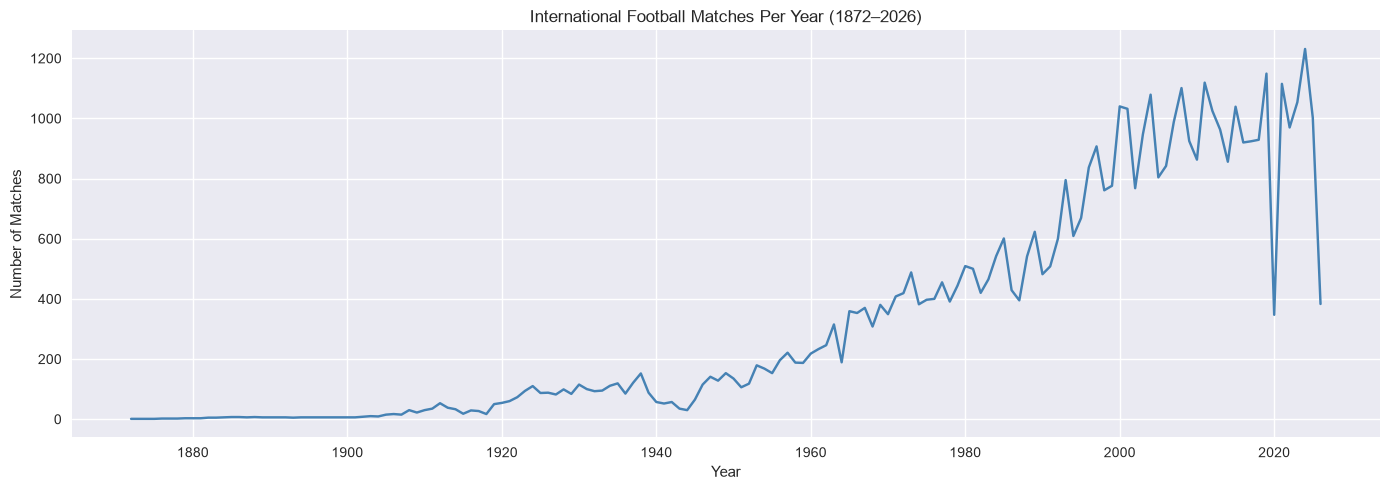

In [5]:
# Convert date to datetime
results['date'] = pd.to_datetime(results['date'])

# Filter for World Cup matches only
wc = results[results['tournament'] == 'FIFA World Cup'].copy()

print(f"Total World Cup matches: {len(wc)}")
print(f"First WC match: {wc['date'].min()}")
print(f"Last WC match: {wc['date'].max()}")

# Plot: number of matches per year (all tournaments)
results['year'] = results['date'].dt.year
matches_per_year = results.groupby('year').size()

plt.figure(figsize=(14, 5))
matches_per_year.plot(kind='line', color='steelblue')
plt.title('International Football Matches Per Year (1872–2026)')
plt.xlabel('Year')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

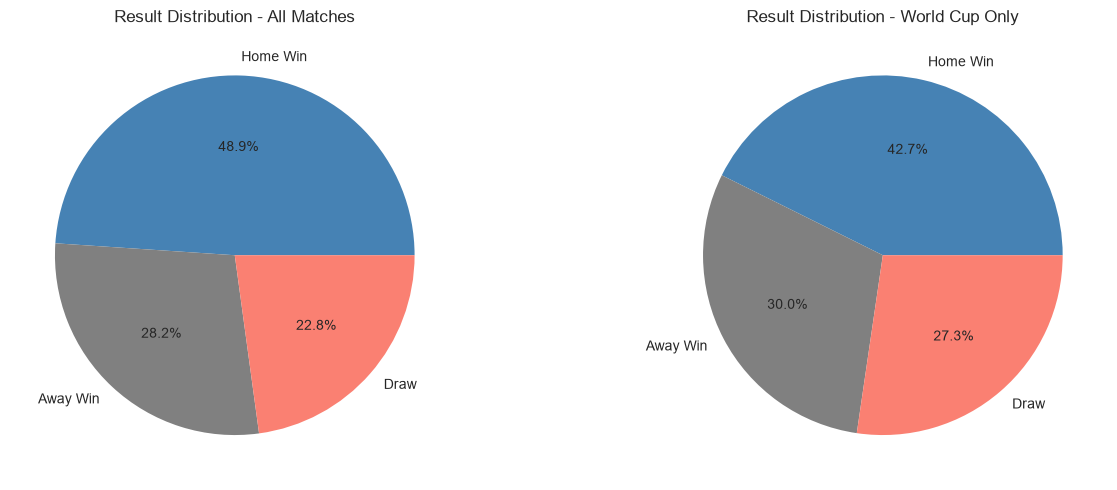

In [6]:
# Goal scoring analysis
results['total_goals'] = results['home_score'] + results['away_score']
results['goal_diff'] = results['home_score'] - results['away_score']

# Create result label
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

results['result'] = results.apply(get_result, axis=1)

# Plot result distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All matches
result_counts = results['result'].value_counts()
axes[0].pie(result_counts, labels=result_counts.index, autopct='%1.1f%%', colors=['steelblue','gray','salmon'])
axes[0].set_title('Result Distribution - All Matches')

# World Cup only
wc['result'] = wc.apply(get_result, axis=1)
wc_result_counts = wc['result'].value_counts()
axes[1].pie(wc_result_counts, labels=wc_result_counts.index, autopct='%1.1f%%', colors=['steelblue','gray','salmon'])
axes[1].set_title('Result Distribution - World Cup Only')

plt.tight_layout()
plt.show()

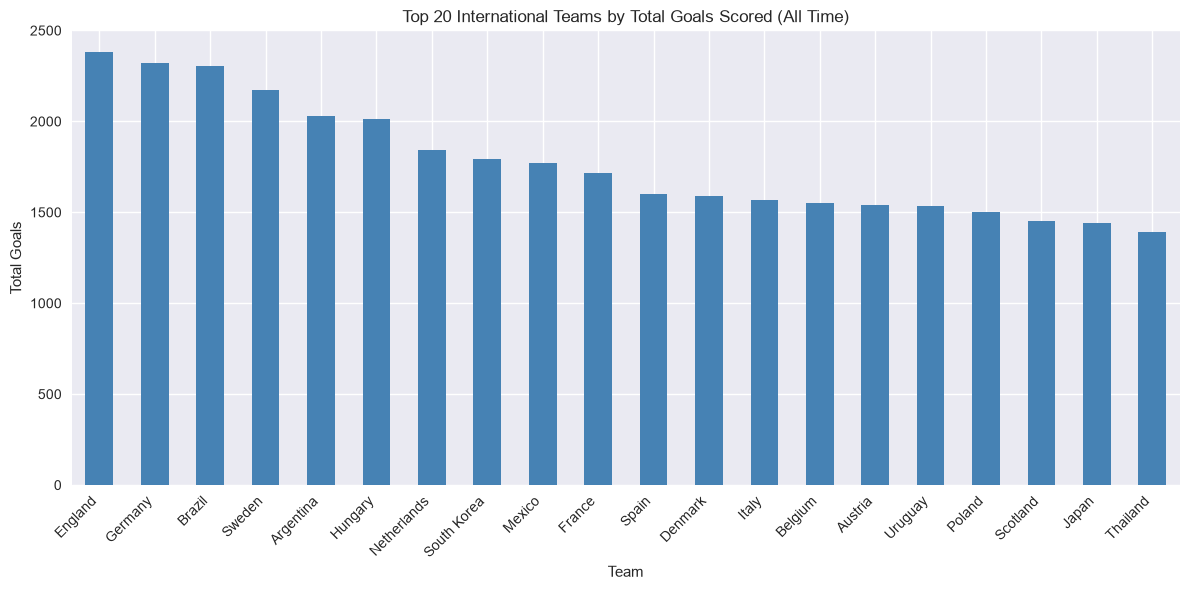

In [7]:
# Top 20 teams by total goals scored
home_goals = results.groupby('home_team')['home_score'].sum()
away_goals = results.groupby('away_team')['away_score'].sum()
total_goals = (home_goals.add(away_goals, fill_value=0)).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
total_goals.plot(kind='bar', color='steelblue')
plt.title('Top 20 International Teams by Total Goals Scored (All Time)')
plt.xlabel('Team')
plt.ylabel('Total Goals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

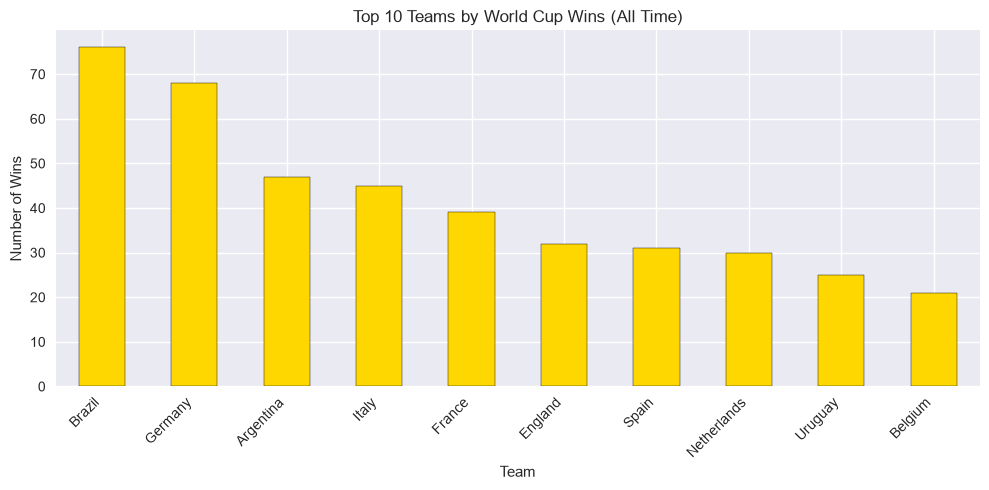

In [8]:
# Top 10 most successful World Cup teams by wins
wc_wins = wc[wc['result'] == 'Home Win'].groupby('home_team').size() + \
           wc[wc['result'] == 'Away Win'].groupby('away_team').size()
wc_wins = wc_wins.fillna(0).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
wc_wins.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 10 Teams by World Cup Wins (All Time)')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()